Building Vision Transformer from scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Resizing,Rescaling,Dense
from tensorflow.keras.layers import Dense,Conv2D,Flatten,InputLayer,BatchNormalization,Dropout,MaxPool2D, Input, GlobalAveragePooling2D
from tensorflow.keras.regularizers import L2,L1
from tensorflow.keras.losses import CategoricalCrossentropy, SparseCategoricalCrossentropy  # Sparse to use when the output is in integar
from tensorflow.keras.metrics import CategoricalAccuracy, TopKCategoricalAccuracy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import RandomRotation,RandomContrast,RandomBrightness,RandomFlip
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention
from tensorflow.keras.models import Model

In [2]:
Configuration = {
    "Batch_Size": 32,
    "Image_Size": 256,
    "Learning_Rate": 0.001,
    "N_Epochs": 2,
    "Dropout_Rate": 0.0,
    "Regularization_Rate": 0.0,
    "N_Filters": 6,
    "Kernel_Size": 3,
    "N_Strides": 1,
    "Pool_Size":2,
    "N_Dense_1": 100,
    "N_Dense_2":10,
    "Num_Class": 3
}

In [3]:
Train_directory = r"C:\Users\ABHAY SINHA\OneDrive\Desktop\TENSORFLOW\Human_Emotion_Detection\Emotions Dataset\Emotions Dataset\train"
Validation_directory = r"C:\Users\ABHAY SINHA\OneDrive\Desktop\TENSORFLOW\Human_Emotion_Detection\Emotions Dataset\Emotions Dataset\test"
Class_Name = ['angry','happy','sad']

In [4]:
Train_Dataset = tf.keras.utils.image_dataset_from_directory(
    Train_directory,labels='inferred',label_mode ='categorical',
    class_names = Class_Name, color_mode = 'rgb',
    batch_size = Configuration["Batch_Size"], image_size = Configuration["Image_Size"], shuffle = True,
    seed = 99, 
    #validation_spilt = 0.2, subset = 'training'
)

Validation_Dataset = tf.keras.utils.image_dataset_from_directory(
    Validation_directory,labels='inferred',label_mode ='categorical',
    class_names = Class_Name, color_mode = 'rgb',
    batch_size = Configuration["Batch_Size"], image_size = Configuration["Image_Size"], shuffle = True,
    seed = 99
)

Found 6799 files belonging to 3 classes.
Found 2278 files belonging to 3 classes.


In [5]:
Resize_Rescale = tf.keras.Sequential([
    Resizing(Configuration["Image_Size"],Configuration["Image_Size"]),
    Rescaling(1.0/255)
])

def Resize_Rescaling(image,label):
    return Resize_Rescale(image, training=True), label

In [6]:
Training_Dataset = (Train_Dataset
                    .map(Resize_Rescaling)
                    .prefetch(tf.data.AUTOTUNE))

Validating_Dataset = (Validation_Dataset
                      .map(Resize_Rescaling)
                      .prefetch(tf.data.AUTOTUNE))

In [7]:
import cv2
Test_Image = cv2.imread(r"C:\Users\ABHAY SINHA\OneDrive\Desktop\TENSORFLOW\Human_Emotion_Detection\Emotions Dataset\Emotions Dataset\test\happy\16484.jpg_rotation_1.jpg")
Test_Image = cv2.resize(Test_Image, (256,256))
Image = tf.constant(Test_Image, dtype=tf.float32)
Image = tf.expand_dims(Image, axis=0)

In [8]:
Patches = tf.image.extract_patches(
    images=Image,
    sizes=[1,16,16,1],
    strides=[1,16,16,1],
    rates=[1,1,1,1],
    padding='VALID'
)

In [9]:
print(Patches.shape)
Patches = tf.reshape(Patches, (Patches.shape[0], -1, 768))
print(Patches.shape)

(1, 16, 16, 768)
(1, 256, 768)


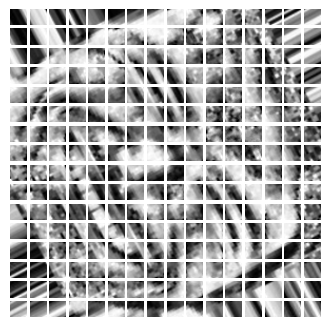

In [10]:
plt.figure(figsize=(4,4))
for i in range(Patches.shape[1]):
    ax = plt.subplot(16,16,i+1)
    patch = tf.reshape(Patches[0,i,:], (16,16,3))

        # normalize to 0-1 for display
    patch = (patch - tf.reduce_min(patch)) / (tf.reduce_max(patch) - tf.reduce_min(patch) + 1e-8)
    plt.imshow(patch)
    plt.axis('off')
    

InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} Index out of range using input dim 3; input has only 3 dims [Op:StridedSlice] name: strided_slice/

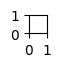

In [11]:
plt.figure(figsize=(4,4))
k = 0

for i in range(14):
    for j in range(14):
        ax = plt.subplot(14,14,k+1)

        patch = tf.reshape(Patches[0,i,j,:], (16,16,3))

        # normalize to 0-1 for display
        patch = (patch - tf.reduce_min(patch)) / (tf.reduce_max(patch) - tf.reduce_min(patch) + 1e-8)

        plt.imshow(patch)
        plt.axis('off')
        k += 1


In [12]:
class PatchEncoder(Layer):
    def __init__(self,N_Patches,Hidden_State):
        super().__init__(name='PatchEncoder')

        self.linear_projection = Dense(Hidden_State)
        self.positional_embedding = Embedding(N_Patches, Hidden_State)
        self.n_patches = N_Patches

    def call(self,x):
        Patches = tf.image.extract_patches(
            images=Image,
            sizes=[1,16,16,1],
            strides=[1,16,16,1],
            rates=[1,1,1,1],
            padding='VALID'
        )
        
        Patches = tf.reshape(Patches,(tf.shape(Patches)[0], -1, Patches.shape[-1]))
        Embedding_Input_Length = tf.range(start=0, limit=self.n_patches, delta = 1)

        Output = self.linear_projection(Patches) + self.positional_embedding(Embedding_Input_Length)

        return Output

In [13]:
Patch_Enc = PatchEncoder(256,768)
Patch_Enc(tf.zeros([1,256,256,3]))

<tf.Tensor: shape=(1, 256, 768), dtype=float32, numpy=
array([[[-198.24919  ,    0.6763521,  -77.45228  , ...,  -59.22834  ,
          -32.55483  ,  -17.19623  ],
        [-343.58765  ,  -77.507744 , -214.37985  , ..., -119.78831  ,
         -131.58676  ,  -95.78504  ],
        [-251.00697  ,  -29.08543  , -147.87231  , ...,  -71.53473  ,
          -34.369766 ,  -75.28629  ],
        ...,
        [-171.71457  ,  -66.43497  , -110.28785  , ...,  -78.05806  ,
          -80.02298  ,  -56.797558 ],
        [-205.97952  ,  -34.746265 , -121.4986   , ...,  -53.174232 ,
          -56.724625 ,  -49.277554 ],
        [-217.45673  ,  -50.4727   , -157.47534  , ...,  -49.85035  ,
          -61.437935 ,  -57.837555 ]]], shape=(1, 256, 768), dtype=float32)>

In [14]:
class TransformerEncoder(Layer):
    def __init__(self,N_Heads,Hidden_State):
        super().__init__(name='TransformerEncoder')

        self.layer_norm_1 = LayerNormalization()
        self.layer_norm_2 = LayerNormalization()
        self.Multi_head = MultiHeadAttention(N_Heads, Hidden_State)

        self.dense_1 = Dense(Hidden_State, activation=tf.nn.gelu)
        self.dense_2 = Dense(Hidden_State, activation=tf.nn.gelu)

    def call(self,input):

        x1 = self.layer_norm_1(input)
        x1 = self.Multi_head(x1, x1)
        x1 = tf.keras.layers.Add()([x1,input])    

        x2 = self.layer_norm_2(x1)
        x2 = self.dense_1(x2)

        output = self.dense_2(x1)
        output = tf.keras.layers.Add()([output, x1])

        return output

In [15]:
Trans_Enc = TransformerEncoder(8,768)
Trans_Enc(tf.zeros([1,256,768]))

<tf.Tensor: shape=(1, 256, 768), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 256, 768), dtype=float32)>

In [16]:
class ViT(Model):
    def __init__(self,N_Heads,Hidden_State,N_Patches, N_Layers,Dense_Units):
        super().__init__(name='Vison_Transformer')
        self.N_Layers = N_Layers
        self.Patch_Encoder = PatchEncoder(N_Patches,Hidden_State)
        self.Transformer_Enocder = [TransformerEncoder(N_Heads,Hidden_State) for _ in range(N_Layers)]
        self.Dense_1 = Dense(Dense_Units, activation=tf.nn.gelu)
        self.Dense_2 = Dense(Dense_Units, activation=tf.nn.gelu)

        self.Dense_3 = Dense(Configuration['Num_Class'], activation='softmax')

    def call(self,input):
        x = self.Patch_Encoder(input)

        for i in range(self.N_Layers):
            x = self.Transformer_Enocder[i](x)

        x = Flatten()(x)
        x = self.Dense_1(x)
        x = self.Dense_2(x)
        
        return self.Dense_3(x)

In [17]:
vit = ViT(N_Heads=8, Hidden_State=768, N_Patches=256, N_Layers=4, Dense_Units=32)
vit(tf.zeros([1,256,256,3]))

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[1., 0., 0.]], dtype=float32)>

In [18]:
vit.summary()

Model: "Vison_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ PatchEncoder (PatchEncoder)     │ ?                      │       787,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TransformerEncoder              │ ?                      │    20,077,824 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TransformerEncoder              │ ?                      │    20,077,824 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TransformerEncoder              │ ?                      │    20,077,824 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TransformerEncoder              │ ?                      │    20,077,824 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (1, 32)                │     6,291,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (1, 32)                │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (1, 3)                 │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,391,139 (333.37 MB)

 Trainable params: 87,391,139 (333.37 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
Loss = CategoricalCrossentropy()
Metrics = [CategoricalAccuracy(name='Accuracy'), TopKCategoricalAccuracy(k=2,name="Top_K_Accuracy")]

In [21]:
ViT.compile(
    optimizer = Adam(learning_rate = Configuration["Learning_Rate"]),
    loss = Loss,
    metrics = Metrics,
)

TypeError: Trainer.compile() missing 1 required positional argument: 'self'

In [ ]:
History = ViT.fit(Training_Dataset, validation_data=Validating_Dataset, epochs=Configuration["N_Epochs"], verbose=1)